# Graph Theory Requirements for Molecule Analysis

This notebook introduces the graph concepts needed for molecular graphs, assay graphs, and bipartite molecule-assay graphs.

Covered topics:
- adjacency matrices
- degrees and connectivity
- Laplacians and spectra
- bipartite graphs
- graph intuition for chemistry and assay data

In [32]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

In [33]:
PROJECT_ROOT = Path.cwd().parent.resolve()
DATA_DIR = Path(os.environ.get("DATA_DIR"))

tox21 = pd.read_csv(DATA_DIR / "tox21.csv")

print("Tox21 shape:", tox21.shape)

Tox21 shape: (7831, 14)


## 1. Molecular Graph Intuition

A molecule can be modeled as a graph where:
- nodes are atoms
- edges are bonds
- node features encode atom properties
- edge features encode bond type or aromaticity

Without RDKit, we can still practice graph math on a hand-built example.

In [34]:
atom_labels = ["C1", "C2", "O3", "H4"]
adjacency = np.array(
    [
        [0, 1, 0, 1],
        [1, 0, 1, 0],
        [0, 1, 0, 0],
        [1, 0, 0, 0],
    ],
    dtype=float,
)
degree = np.diag(adjacency.sum(axis=1))
laplacian = degree - adjacency
eigenvalues = np.linalg.eigvalsh(laplacian)

display(pd.DataFrame(adjacency, index=atom_labels, columns=atom_labels))
print("Degree sequence:", np.diag(degree))
print("Laplacian eigenvalues:", np.round(eigenvalues, 4))

,C1,C2,O3,H4
C1,0.0,1.0,0.0,1.0
C2,1.0,0.0,1.0,0.0
O3,0.0,1.0,0.0,0.0
H4,1.0,0.0,0.0,0.0


Degree sequence: [2. 2. 1. 1.]
Laplacian eigenvalues: [-0.      0.5858  2.      3.4142]


## 2. Connectivity and Shortest-Path Intuition

Important graph-theory requirements:
- connected components
- path length
- degree centrality
- local neighborhoods

These ideas matter because message-passing GNNs aggregate information from graph neighborhoods.

,atom,degree
0,C1,2.0
1,C2,2.0
2,O3,1.0
3,H4,1.0


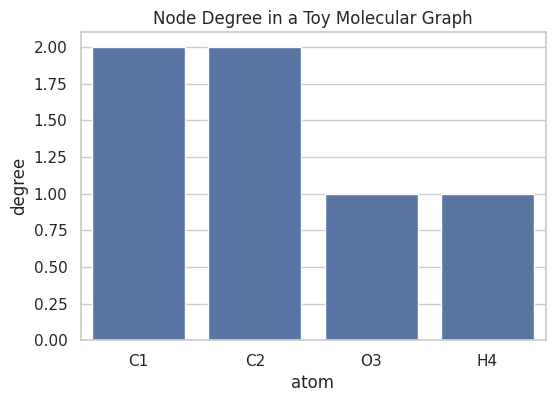

In [35]:
degrees = adjacency.sum(axis=1)
degree_df = pd.DataFrame({"atom": atom_labels, "degree": degrees})
display(degree_df)

plt.figure(figsize=(6, 4))
sns.barplot(data=degree_df, x="atom", y="degree")
plt.title("Node Degree in a Toy Molecular Graph")
plt.show()

## 3. Bipartite Graphs for Molecule-Assay Data

A molecule-assay dataset can also be viewed as a bipartite graph:
- one partition is molecules
- the other partition is assays
- an edge indicates activity or measured participation

This is especially useful for Tox21, SIDER, MUV, and ToxCast.

,assay,active_edges_in_sample
0,SR-ARE,4.0
1,NR-AhR,3.0
2,NR-ER,3.0
3,NR-ER-LBD,1.0
4,SR-ATAD5,1.0
5,SR-HSE,1.0
6,SR-p53,1.0
7,NR-PPAR-gamma,1.0
8,NR-Aromatase,0.0
9,NR-AR-LBD,0.0


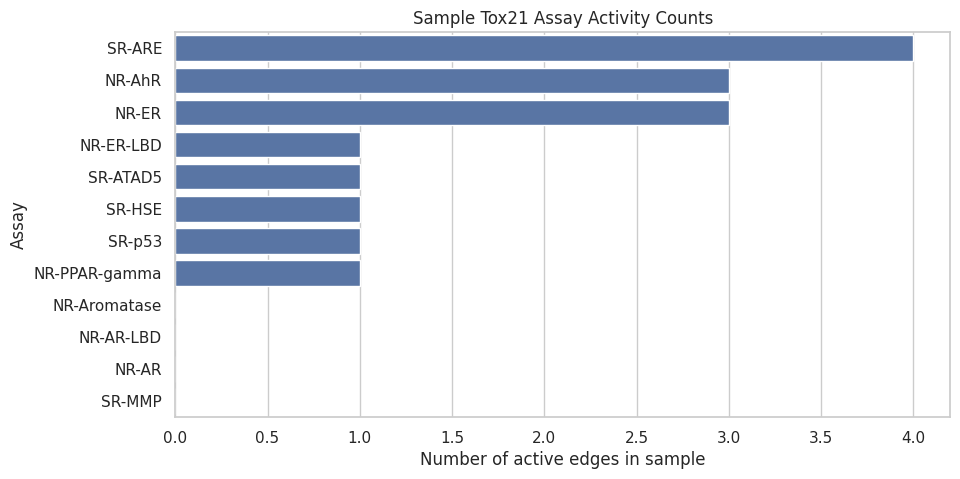

In [36]:
sample = tox21.head(25).copy()
assay_cols = [col for col in tox21.columns if col not in {"mol_id", "smiles"}]
activity_counts = sample[assay_cols].fillna(0).sum().sort_values(ascending=False)
activity_df = activity_counts.reset_index()
activity_df.columns = ["assay", "active_edges_in_sample"]
display(activity_df.head(12))

plt.figure(figsize=(10, 5))
sns.barplot(data=activity_df.head(12), x="active_edges_in_sample", y="assay")
plt.title("Sample Tox21 Assay Activity Counts")
plt.xlabel("Number of active edges in sample")
plt.ylabel("Assay")
plt.show()

## 4. Laplacian and Spectral Intuition

Core requirements:
- adjacency matrix $A$
- degree matrix $D$
- graph Laplacian $L = D - A$
- eigenvalues of $L$

Why this matters:
- graph spectra summarize connectivity structure
- molecular graph spectra can encode shape and topology
- spectral ideas motivate some graph embeddings and graph neural architectures

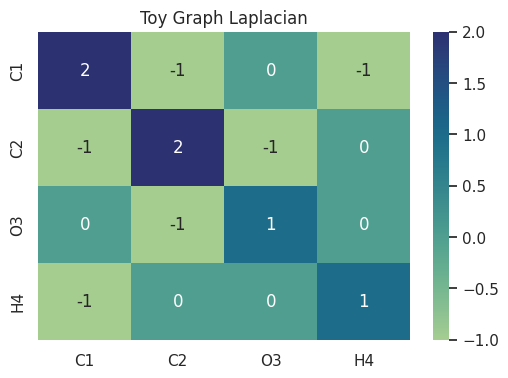

In [37]:
plt.figure(figsize=(6, 4))
sns.heatmap(
    laplacian,
    annot=True,
    cmap="crest",
    xticklabels=atom_labels,
    yticklabels=atom_labels,
)
plt.title("Toy Graph Laplacian")
plt.show()

## Minimum Readiness Checklist

A learner is ready for later graph notebooks when they can:
- read an adjacency matrix
- compute node degree and Laplacian
- explain what a bipartite molecule-assay graph represents
- explain why local neighborhoods matter for molecular learning
- interpret Laplacian eigenvalues as structural signals